# **Project Name**    -  **Exploratory Data Analayis on Amazon Prime TV Shows and Movies**



##### **Project Type**    - EDA On Amazon Prime TV Shows and Movies
##### **Contribution**    - Individual

# Github Link
### https://github.com/darxonxz/DSML.git

# **Problem Statement**


**BUSINESS PROBLEM OVERVIEW**


This dataset was created to analyze all shows available on Amazon Prime Video, allowing us to extract valuable insights such as:

* Content Diversity: What genres and categories dominate the platform?
* Regional Availability: How does content distribution vary across different regions?
* Trends Over Time: How has Amazon Prime’s content library evolved?
* IMDb Ratings & Popularity: What are the highest-rated or most popular shows on the platform?
* By analyzing this dataset, businesses, content creators, and data analysts can uncover key trends that influence subscription growth, user engagement, and content investment strategies in the streaming industry.

#### **Define Your Business Objective?**

*** Analyse Amazon Prime Video data to identify trends and insights ***


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







#  **Dataset Description**

This data set was created to list all shows available on Amazon Prime streaming, and analyze the data to find interesting facts. This dataset has data available in the United States.

This dataset has two files containing the titles (titles.csv) and the cast (credits.csv) for the title.

This dataset contains +9k unique titles on Amazon Prime with 15 columns containing their information, including:

id: The title ID on JustWatch.
title: The name of the title.
show_type: TV show or movie.
description: A brief description.
release_year: The release year.
age_certification: The age certification.
runtime: The length of the episode (SHOW) or movie.
genres: A list of genres.
production_countries: A list of countries that produced the title.
seasons: Number of seasons if it's a SHOW.
imdb_id: The title ID on IMDB.
imdb_score: Score on IMDB.
imdb_votes: Votes on IMDB.
tmdb_popularity: Popularity on TMDB.
tmdb_score: Score on TMDB.
And over +124k credits of actors and directors on Amazon Prime titles with 5 columns containing their information:

person_ID: The person ID on JustWatch.
id: The title ID on JustWatch.
name: The actor or director's name.
character_name: The character name.
role: ACTOR or DIRECTOR.


```
Main Libraries to be used:
```

Pandas for data manipulation, aggregation
Matplotlib and Seaborn for visualization and behavior with respect to the target variable. Use at least 5 different visualizations.
NumPy for computationally efficient operations

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

import warnings
warnings.filterwarnings('ignore')

!git clone https://github.com/darxonxz/DSML
import os
os.listdir("DSML")

fatal: destination path 'DSML' already exists and is not an empty directory.


['README.md', 'credits.csv', '.git', 'titles.csv']

### Dataset Loading

In [ ]:
# Load Dataset for PaisaBazaar
def loaddataset():
    ''' Loading 2 datasets as required
    * titles.csv -------(tls)
    * credits.csv ------(crds)'''

    titles = pd.read_csv("DSML/titles.csv")
    credits = pd.read_csv("DSML/credits.csv")

    print(''' Loading 2 datasets as required
    * titles.csv -------(tls)
    * credits.csv ------(crds)''')

    return titles,credits

In [ ]:
titles, credits = loaddataset() #loading the dataset of titles and credits from

 Loading 2 datasets as required
    * titles.csv -------(tls)
    * credits.csv ------(crds)


In [ ]:
titles.head(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8


### Dataset First View

In [ ]:
# Dataset copied first
tls = titles.copy()
crds = credits.copy()
tls_alt = titles.copy() # for undisturbed data

In [ ]:
# Convert stringified lists into actual Python lists
import ast

# Ensure tls is a fresh copy of titles to prevent issues from re-running the cell
tls = titles.copy()

# Safely convert stringified lists to actual Python lists
# Only apply ast.literal_eval if the value is a string, otherwise keep it as is
tls['genres'] = tls['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
tls['production_countries'] = tls['production_countries'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# This “explodes” list entries so that each genre/country gets its own row.
# Chain the explode calls to apply both to the same DataFrame
tls = tls.explode('genres').explode('production_countries')

In [ ]:
tls.head(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,comedy,US,26.0,tt0850645,8.6,1092.0,15.424,7.6
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,family,US,26.0,tt0850645,8.6,1092.0,15.424,7.6
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,animation,US,26.0,tt0850645,8.6,1092.0,15.424,7.6


In [ ]:
tls.tail(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,family,NaN,NaN,tt14331982,8.4,49.0,0.645,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,drama,NaN,NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,drama,NaN,1.0,tt13542552,NaN,NaN,NaN,NaN


In [ ]:
crds.head(3)

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR


In [ ]:
crds.tail(3)

,person_id,id,name,character,role
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR
124234,1938620,tm1054116,Vishwa Bhanu,NaN,DIRECTOR


### Dataset Rows & Columns count

In [ ]:
# DataBase Total Rows & Columns
crds.shape, tls.shape

((124235, 5), (25824, 15))

### Dataset Information

In [ ]:
# Dataset Info
crds.info(), tls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 25824 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    25824 non-null  object 
 1   title                 25824 non-null  object 
 2   type                  25824 non-null  object 
 3   description           25678 non-null  object 
 4   release_year          25824 non-null  int64  
 5   age_certification     11224 non-null  object 
 6   runtime               25824 non-null  int64 

(None, None)

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count

x = len(tls[tls.duplicated()])
print(f"length of duplicates in tls DataFrame is {x}")
y = len(crds[crds.duplicated()])
print(f"length of duplicates in crds DataFrame is {y}")

tls = tls.drop_duplicates(subset=['id']) # droping columns wrt id
crds = crds.drop_duplicates(subset=['id']) # droping columns wrt id
print("Duplicates Neutralised")

length of duplicates in tls DataFrame is 5
length of duplicates in crds DataFrame is 56
Duplicates Neutralised


In [ ]:
# Merge two dataframes on id such that titles and credits goes in a single dataframe
ttldat = pd.merge(tls, crds, on = 'id', how = 'left')
df = ttldat.copy()
ttldat = ttldat.to_csv("Amazon_prime.csv")

In [ ]:
df.head(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,comedy,US,26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,action,US,NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,romance,US,NaN,tt0036868,8.1,63026.0,8.435,7.8,29993.0,Myrna Loy,Milly Stephenson,ACTOR


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(df.isnull().sum())

id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6484
runtime                    0
genres                   209
production_countries     821
seasons                 8511
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2080
person_id               1007
name                    1007
character               1916
role                    1007
dtype: int64


In [ ]:
# Null Values adjusted with median / grouped median by type and fill important NA attributes
df["imdb_score"] = df.groupby("type")["imdb_score"].transform(lambda x: x.fillna(x.median()))
df["tmdb_score"] = df.groupby("type")["tmdb_score"].transform(lambda x: x.fillna(x.median()))
df["imdb_votes"] = df["imdb_votes"].fillna(tls["imdb_votes"].median())
df['description'] = df['description'].fillna("No description available")
df['genres'] = df['genres'].fillna("No description available")
df['production_countries'] = df['production_countries'].fillna("No description available")
df['imdb_id'] = df['imdb_id'].fillna("Unknown imdb_id")
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(tls['tmdb_popularity'].median())
df['person_id'] = df['person_id'].fillna("Unknown_person_id")
df['name'] = df['name'].fillna("Unknown_name")
df['role'] = df['role'].fillna("Unknown_role")

### What did you know about your dataset?

This dataset has two files containing the titles (titles.csv) and the cast (credits.csv) for the title.

This dataset prepared named df contains 9737 unique titles on Amazon Prime with 19 columns containing their information, including:

* No. of title are 9737.
* No. of media types are 2.
* Release year from 1912 to 2022
* No. of genres are 20.
* No. of production_countries are 102.
* No. of Actors and Directors are 6632.
* No. characters is 6177.
* No. of roles are 2.

VVIP. df dataset had many null values so the unknown categorical columns were replaced with "unknown ###" where hash will be its column names.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
# you can use pb.columns also but I used pb.dtypes in order to know our data types too
df.dtypes

,0
id,object
title,object
type,object
description,object
release_year,int64
age_certification,object
runtime,int64
genres,object
production_countries,object
seasons,float64


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print(f"No. of unique values in {i} is {df[i].nunique()}.")

No. of unique values in id is 9868.
No. of unique values in title is 9737.
No. of unique values in type is 2.
No. of unique values in description is 9735.
No. of unique values in release_year is 110.
No. of unique values in age_certification is 11.
No. of unique values in runtime is 207.
No. of unique values in genres is 20.
No. of unique values in production_countries is 102.
No. of unique values in seasons is 32.
No. of unique values in imdb_id is 9202.
No. of unique values in imdb_score is 86.
No. of unique values in imdb_votes is 3650.
No. of unique values in tmdb_popularity is 5325.
No. of unique values in tmdb_score is 89.
No. of unique values in person_id is 6640.
No. of unique values in name is 6632.
No. of unique values in character is 6177.
No. of unique values in role is 3.


In [ ]:
# Dataset Describe (Summarise)

df.describe(include='all')

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
count,9868,9868,9868,9868,9868.000000,3384,9868.000000,9868,9868,1357.000000,9868,9868.000000,9.868000e+03,9868.000000,9868.000000,9868,9868,7952,9868
unique,9868,9737,2,9735,NaN,11,NaN,20,102,NaN,9202,NaN,NaN,NaN,NaN,6640,6632,6177,3
top,ts275838,The Lost World,MOVIE,No description available,NaN,R,NaN,drama,US,NaN,Unknown imdb_id,NaN,NaN,NaN,NaN,Unknown_person_id,Unknown_name,Himself,ACTOR
freq,1,3,8511,119,NaN,1249,NaN,2626,4999,NaN,667,NaN,NaN,NaN,NaN,1007,1007,356,8605
mean,NaN,NaN,NaN,NaN,2001.345561,NaN,85.979124,NaN,NaN,2.791452,NaN,5.995713,7.693079e+03,6.669645,6.044923,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,25.792295,NaN,33.515714,NaN,NaN,4.148958,NaN,1.285893,4.353210e+04,29.182245,1.379506,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1912.000000,NaN,1.000000,NaN,NaN,1.000000,NaN,1.100000,5.000000e+00,0.000011,0.800000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1996.000000,NaN,65.000000,NaN,NaN,1.000000,NaN,5.300000,1.380000e+02,1.307750,5.400000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2014.000000,NaN,89.000000,NaN,NaN,1.000000,NaN,5.900000,4.640000e+02,2.537000,6.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2018.000000,NaN,102.000000,NaN,NaN,3.000000,NaN,6.900000,1.763250e+03,5.300250,6.900000,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

# 3. Visualization

#### Figure 1. ** Bar Chart & Pie Chart for different types of Medias i.e. movies/shows. **

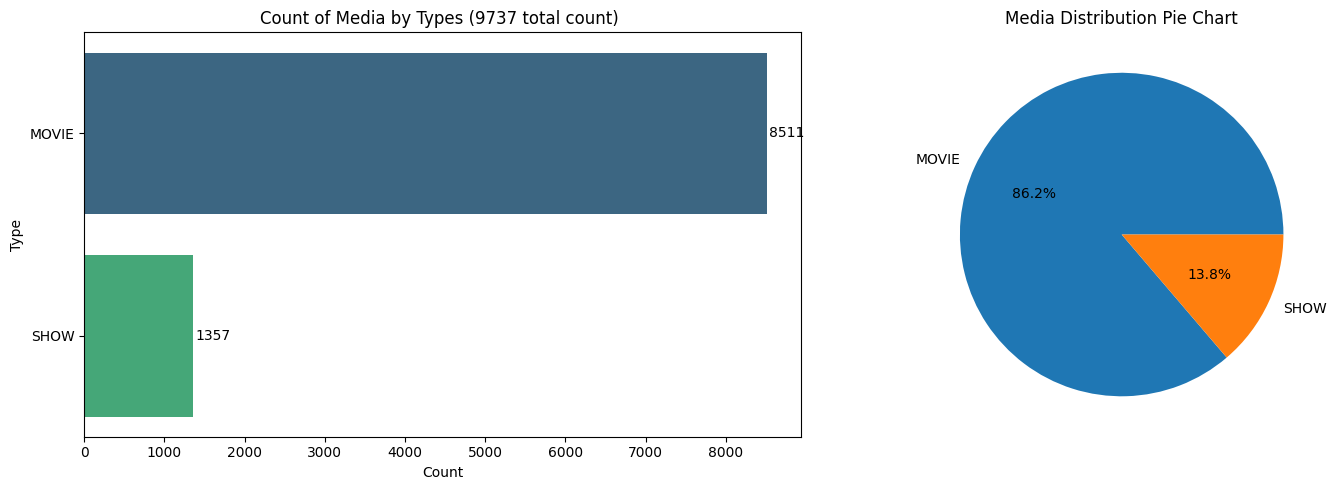

In [ ]:
fone = df.groupby('type')['id'].nunique().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- Bar Plot ---
# Bar plot on the first Axes object (ax[0])
barplot_ax = sns.barplot(data=fone, y='type', x='id', hue='type', ax=ax[0], palette='viridis', legend=False)
ax[0].set_title('Count of Media by Types (9737 total count) ')
ax[0].set_xlabel('Count')
ax[0].set_ylabel('Type')

# Add labels on top of bars for the barplot_ax
for container in barplot_ax.containers:
    barplot_ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

# --- Pie Chart ---
# Pie chart on the second Axes object (ax[1])
ax[1].pie(
    fone['id'],
    labels=fone['type'],
    autopct='%1.1f%%'
)
ax[1].set_title("Media Distribution - Pie Chart")

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Observation: In the dataset, the observations include 8511 movies and 1357 shows. Pie format shown as 86.2% of movies and 13.8% as shows.

#### Figure 2. ** Number of media per genre. **

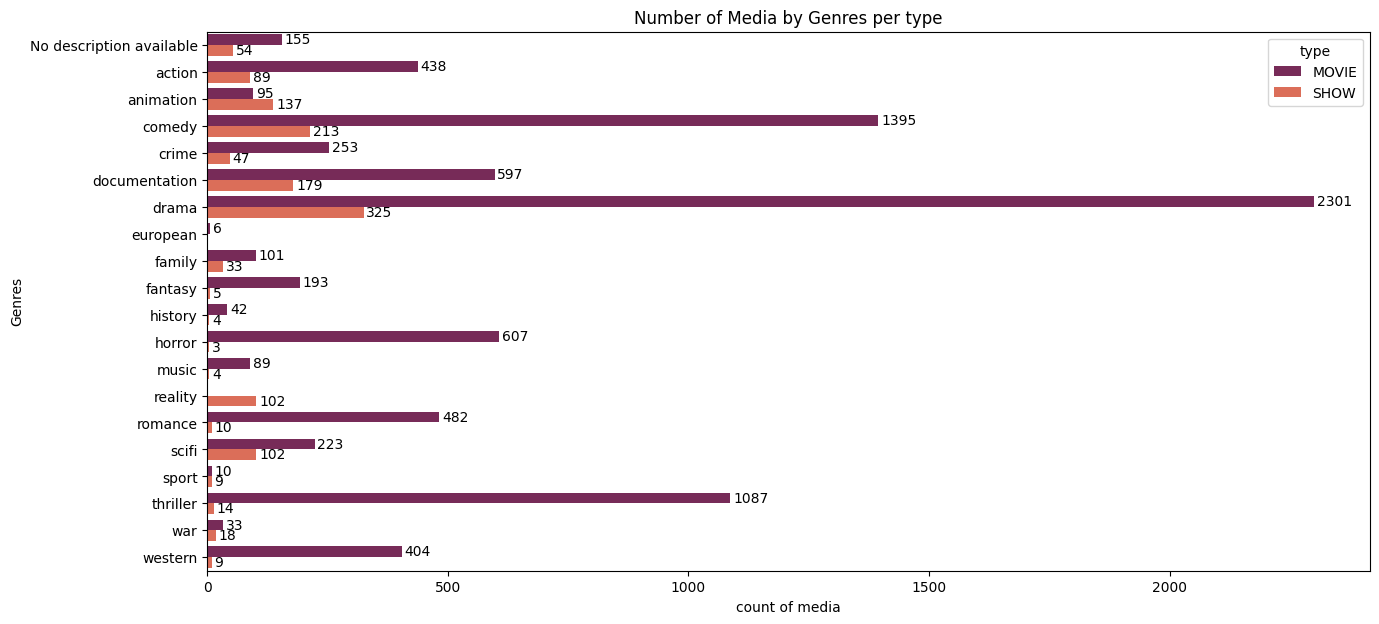

In [ ]:
ftwo = df.groupby(['genres', 'type'])['id'].nunique().reset_index()

# countplot for different genres of media
plt.figure(figsize=(15, 7))
barplot_ax = sns.barplot(data=ftwo, y='genres', x='id', hue='type', palette='rocket')

# Add labels on top of bars for the barplot_ax
for container in barplot_ax.containers:
    barplot_ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

barplot_ax.set_title('Number of Media by Genres')
barplot_ax.set_xlabel('count of media')
barplot_ax.set_ylabel('Genres')
barplot_ax.tick_params(axis='x')
plt.show()

Observation: The genre with the highest production of movies and shows is Drama, with 2301 movies and 325 shows whereas reality genre having 0 movies and european genre has 0 shows.

#### Figure 3. ** Number of Titles Released per Year **

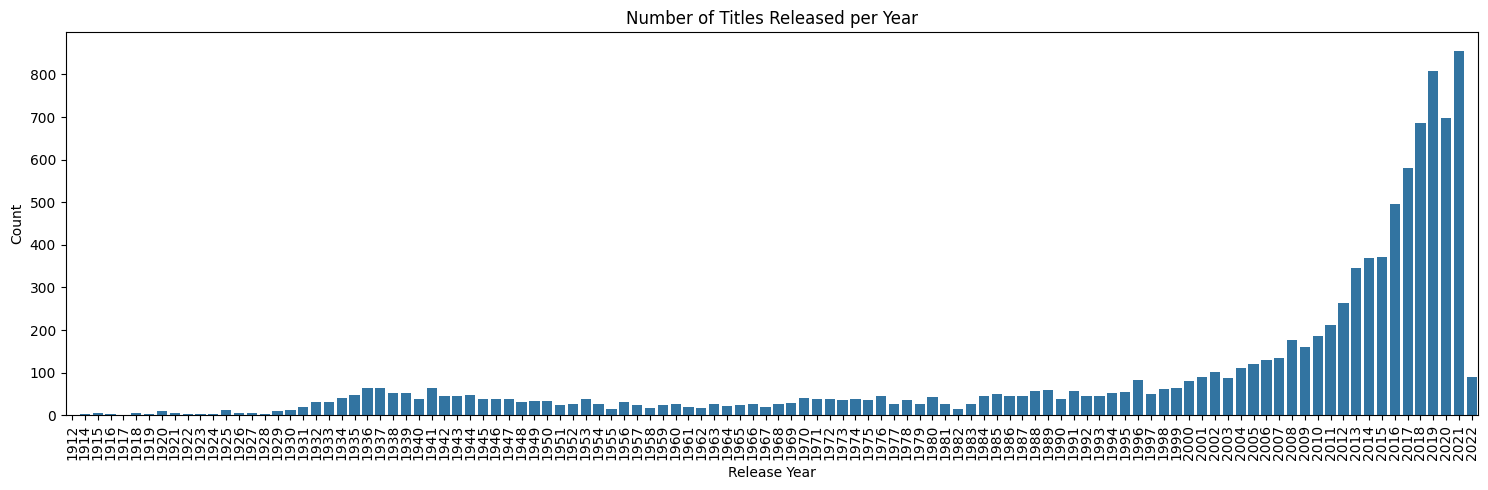

In [ ]:
plt.figure(figsize=(15,5))

sns.countplot(
    data=df,
    x="release_year",
    order=sorted(df["release_year"].unique()),
)

plt.title("Number of Titles Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Observation: Media production increased steadily from 2001 to 2011, followed by a noticeable spike after 2011. With max number of movies in 2021

#### **Figure 4. Distribution of IMDb scores Vs TMDB Scores**

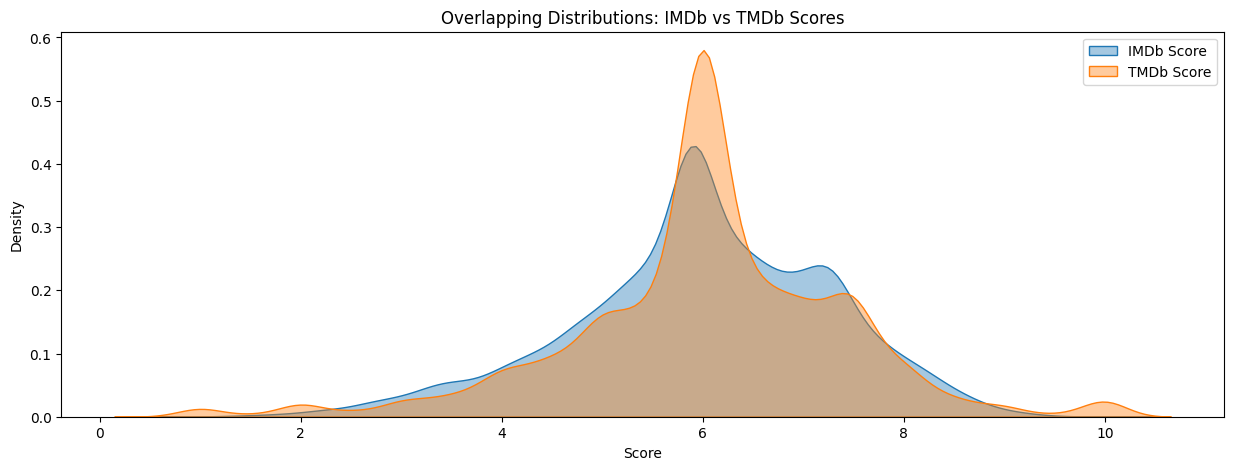

In [ ]:
plt.figure(figsize=(15,5))

sns.kdeplot(df["imdb_score"], fill=True, alpha=0.4, label="IMDb Score")
sns.kdeplot(df["tmdb_score"], fill=True, alpha=0.4, label="TMDb Score")

plt.title("Overlapping Distributions: IMDb vs TMDb Scores")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()

Observation: Both scores show a similar trend of a normal distribution, slightly skewed to the right of the mean (5). TMDb scores minutely tend to cluster more around 6 compared to IMDb with more ratings peaked towards (6) wrt to TMDb scores.

In [ ]:
# Joining both the csv files as per unique id's.
actps = pd.merge(tls[['id','title', 'release_year','type', 'production_countries']],crds[['id', 'name', 'role']], on = 'id', how = 'left')
actps.head(3)

,id,title,release_year,type,production_countries,name,role
0,ts20945,The Three Stooges,1934,SHOW,US,Joe Besser,ACTOR
1,tm19248,The General,1926,MOVIE,US,Buster Keaton,ACTOR
2,tm82253,The Best Years of Our Lives,1946,MOVIE,US,Myrna Loy,ACTOR


#### **Figure 5. Distribution of roles Actors vs Directors**

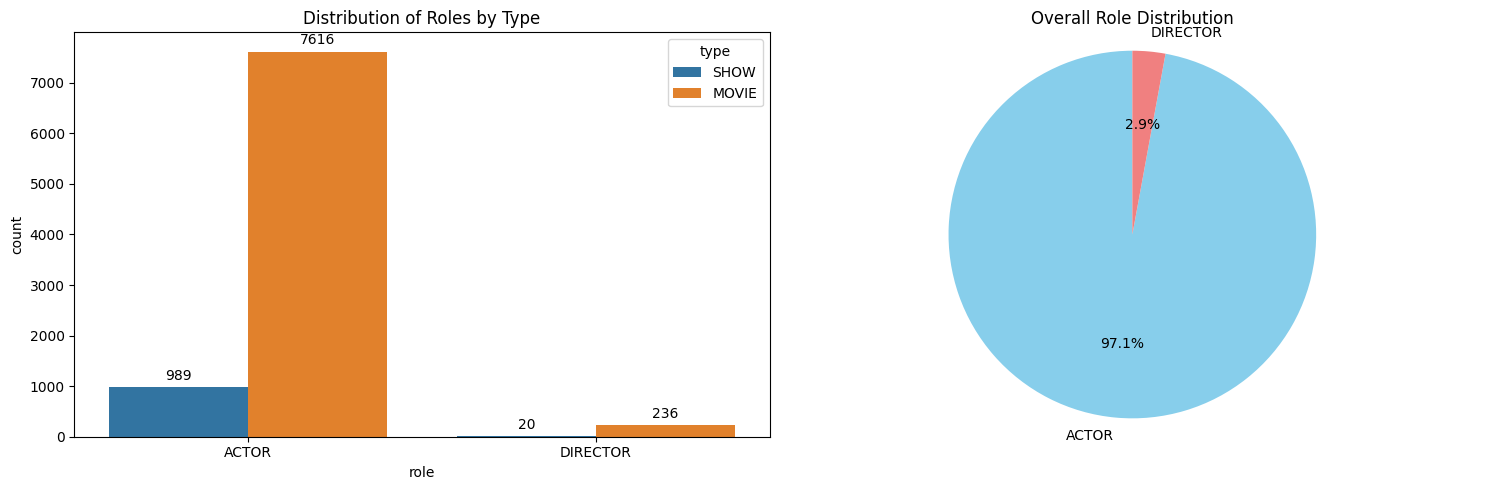

In [ ]:
x = actps.groupby(['title', 'type'])['role'].nunique().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot for distribution of roles by type
barplot_ax = sns.countplot(data=actps, x="role", hue="type", ax=ax[0])
ax[0].set_title("Distribution of Roles by Type") # Set title for the first subplot

# Add labels on top of bars for the barplot_ax
for container in barplot_ax.containers:
    barplot_ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# Calculate the overall distribution of roles for the pie chart
role_distribution = actps['role'].value_counts().reset_index()
role_distribution.columns = ['role', 'count']

# Pie chart on the second Axes object (ax[1])
ax[1].pie(role_distribution['count'], labels=role_distribution['role'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen'])
ax[1].set_title('Overall Role Distribution') # Set title for the second subplot
ax[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Observation: The countplot reveals actors and directors created more movies (Movies = 7616 actor counts & 236 director counts).  

#### **Figure 6. Countries wise distribution of titles**

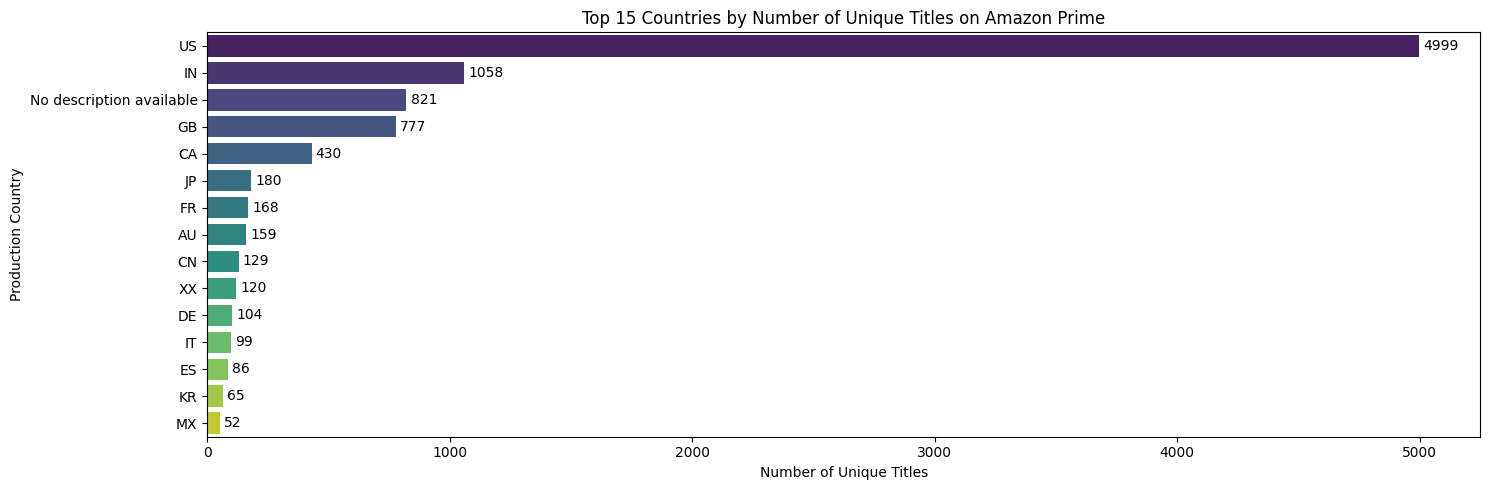

In [ ]:
import ast # Ensure ast is available

# Group by 'production_countries' and count the number of unique titles ('id')
country_distribution = df.groupby('production_countries')['id'].nunique().reset_index()

# Sort the countries by the number of unique titles in descending order
country_distribution = country_distribution.sort_values(by='id', ascending=False)

# Select the top 15 countries for better visualization readability
top_15_countries = country_distribution.head(15)

# Chart visualization code
plt.figure(figsize=(15, 5))
ax = sns.barplot(x='id', y='production_countries', data=top_15_countries, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Top 15 Countries by Number of Unique Titles on Amazon Prime')
plt.xlabel('Number of Unique Titles')
plt.ylabel('Production Country')
plt.tight_layout()
plt.show()

Observation: US Having most contribution for media then to India, Great Britain, Canada, Japan and so on with least amount of movies in mexico.

#### **Figure 7. Correlation Matrix**

<Axes: >

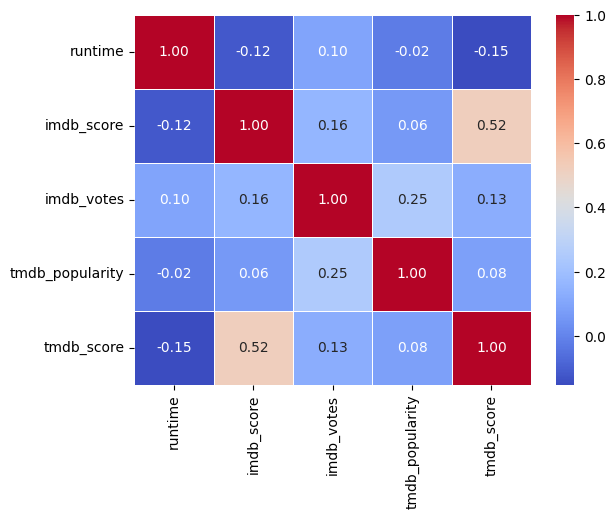

In [ ]:
x = df[['runtime', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']].corr()

sns.heatmap(
    x,
    annot=True,      # show values on the heatmap
    fmt=".2f",
    cmap="coolwarm", # color theme
    linewidths=.5
)

Observation every category has positive correlation with each other except (tmdb_score to runtime), (tmbd_popularity to runtime), (imdb_score to runtime) that means more run time gives less ratings and popularity and vice a versa yet the correlation scores are negligibe as most of them are less than 0.16. Whereas highest +ve correlation is with tmdb scores to imdb scores and vice versa.

# 4. Project Summary

---
'Amazon Prime TV Shows and Movies'
---
---

Conclusion – The analysis of Amazon Prime Video data reveals strong trends in content distribution, genre preferences, production growth, and audience ratings. Movies dominate the platform significantly, making up over 86% of all titles, while TV shows represent only 13.8%. This imbalance clearly indicates that Prime Video’s library prioritizes movie content over long-form television.

Genre exploration shows **Drama** as the most prominent category, far surpassing other genres in both movies and shows. In contrast, categories like **Reality** and **Music** are minimally represented, indicating niche or limited production in these areas. Examining release-year trends, content production steadily increased from 2001 to 2011 before experiencing a sharp rise, with 2021 marking the highest output—reflecting Amazon’s expanding investment in content creation over the past decade.

Rating distributions from IMDb and TMDb follow a similar pattern: both display a near-normal distribution slightly skewed to the right, centered around a rating of 5, though TMDb ratings cluster more closely around 6. This suggests generally moderate viewer reception across the platform’s content. Participation analysis shows a significantly higher number of actor entries compared to director entries, indicating greater cast diversity.

Lastly, country-based production analysis highlights the **United States** as the leading contributor to Prime Video’s catalog, followed by India, Great Britain, Canada, and Japan, with Mexico contributing the least. Overall, these insights offer valuable understanding for content strategists, marketing teams, and investors by revealing production patterns, rating behavior, and dominant market contributors.

---
